## Register High-res H&E, Cy-IF & DESI WSI series W/ VALIS

In [1]:
import os
import sys
import gc

import gcsfs
import tifffile
import numpy as np
import pandas as pd
import seaborn as sns

from skimage import io


In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams.update({'font.size': 10})
rcParams.update({'figure.dpi': 300})

import warnings
warnings.filterwarnings('ignore')

In [3]:
import sys
sys.path.append('..')
sys.path.append('../util/')
import registration, IO

### H&E alignment

#### Data loading & alignment

In [125]:
def disp_chans(img, title=None, ncols=4):
    depth = len(img)
    nrows = depth // ncols if depth % ncols == 0 else depth // ncols + 1
    
    idx = 0
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3.2*nrows))
    for r in range(nrows):
        for c in range(ncols):
            if idx >= depth:
                axes[r, c].axis('off')
                continue
            axes[r, c].imshow(img[idx])
            idx += 1
            
    fig.tight_layout()
    fig.suptitle(title, y=1.01)
    plt.show()

In [ ]:
data_path = '../data/desi/post_desi_HE/'
res_path = '../data/desi/post_desi_HE_aligned/'
ref_slide = 'HE_slice_48.tif'

filenames = [f for f in sorted(os.listdir(data_path))
             if f[-3:] == 'tif']

imgs = [tifffile.imread(os.path.join(data_path, f))
        for f in filenames]


In [ ]:
registrar, _, _ = registration.run_valis(src_dir=data_path,
                                         res_dir=res_path,
                                         ref_slide=ref_slide,
                                         micro=False,
                                         kill_jvm=True)

In [ ]:
# Generate overlayed H&E WSI series
aligned_imgs = [tifffile.imread(os.path.join(res_path, 'registered_slides', f))
                for f in sorted(os.listdir(os.path.join(res_path, 'registered_slides')))
                if f[-8:] == 'ome.tiff']

aligned_imgs = np.array(aligned_imgs)
aligned_imgs = aligned_imgs.transpose((3,0,1,2))
tifffile.imwrite(os.path.join(res_path, 'valis_stacked.ome.tif'), aligned_imgs, metadata={'axes': 'CZYX'})

del aligned_imgs

#### Evaluation

- Comparison of registration results btw `rigid`, `non-rigid` & `micro-registration`

In [ ]:
# Per-slice errors before & after alignment
summary_df = pd.read_csv(os.path.join(res_path, 'data/_summary.csv'), index_col=[0])
summary_df.head()

In [ ]:
# rTRE score: relative Target Registration Error
# (avg. normed. dist btw landmarks from "src" to "dst")

nslides = summary_df.shape[0]

rTRE_df = pd.DataFrame({
    'name': nslides*['orig'] + nslides*['rigid'] + nslides*['non-rigid'],
    'rTRE': summary_df['original_rTRE'].to_list() + summary_df['rigid_rTRE'].to_list() + summary_df['non_rigid_rTRE'].to_list()
})

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='name', y='rTRE', data=rTRE_df,
               palette=['cyan','g','orange'], ax=ax)
ax.set_title('relative Target Registration Error')
plt.show()

In [ ]:
nr_margin_df = pd.DataFrame({
    'name': nslides*['rigid'] + nslides*['non-rigid'],
    'rTRE': summary_df['rigid_rTRE'].to_list() + summary_df['non_rigid_rTRE'].to_list()
})

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='name', y='rTRE', data=nr_margin_df,
            palette=['g','orange'], ax=ax)

ax.set_title('Rigid vs. Non-rigid')
plt.show()

Both non-rigid & micro-registration introduces artifacts outside the registered bounding-box (likely introduced from VALIS's pyramid schemes); Trim off before using the images)

---

### Post-modality H&E alignment

Cross-alignment btw H&E only slices & post-CyCIF H&E slices

In [ ]:
from importlib import reload
reload(registration)

In [ ]:
def disp_chans(img, title=None, ncols=4):
    depth = len(img)
    nrows = depth // ncols if depth % ncols == 0 else depth // ncols + 1
    
    idx = 0
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 3.2*nrows))
    for r in range(nrows):
        for c in range(ncols):
            if idx >= depth:
                axes[r, c].axis('off')
                continue
            axes[r, c].imshow(img[idx])
            idx += 1
            
    fig.tight_layout()
    fig.suptitle(title, y=1.01)
    plt.show()


In [4]:
# Load post-H&E slices from gcloud
# CREDENTIAL_PATH = "../data/azizilab-cell-segmentation-05f1a1125db2.json"
# PROJECT_ID = 'azizilab-cell-segmentation'
# BUCKET_ID = 'liver_3d'
# HOME_PATH = 'CyIF/H&E_post_CyIF'

# he_reader = IO.GcloudReader(CREDENTIAL_PATH,
#                             PROJECT_ID,
#                             BUCKET_ID,
#                             HOME_PATH)


# he_imgs = he_reader.load_imgs()

# Load H&E post-H&E slices locally
data_path = '../data/desi/post_desi_HE/'
res_path = '../data/desi/post_desi_HE_aligned/'
ref_slide = 'HE_slice_48.tif'

filenames = [f for f in sorted(os.listdir(data_path))
             if f[-3:] == 'tif']

he_imgs = [tifffile.imread(os.path.join(data_path, f))
        for f in filenames]

print(len(he_imgs))

12


In [ ]:
disp_chans(he_imgs)

#### Data loading & alignment

In [ ]:
# data_path = '../data/he_imgs/raw/'
# res_path = '../data/he_imgs/res/'
# ref_slide = 'HE_33.tif'

# registrar, _, _ = registration.run_valis(src_dir=data_path,
#                                          res_dir=res_path,
#                                          ref_slide=ref_slide,
#                                          align_to_ref=False,
#                                          micro=False,
#                                          kill_jvm=False)

# registration.kill_jvm()
# gc.collect()

# # Generate overlayed H&E WSI series
# aligned_imgs = [tifffile.imread(os.path.join(res_path, 'registered_slides', f))
#                 for f in sorted(os.listdir(os.path.join(res_path, 'registered_slides')))
#                 if f[-8:] == 'ome.tiff']

# aligned_imgs = np.array(aligned_imgs)
# aligned_imgs = aligned_imgs.transpose((3,0,1,2))

End-to-end registration X work, develop customized Affine transformation followed by in-place Non-rigid transformation:

- Affine transformation w/ self-annotated points(unify shapes)
- Non-rigid alignment w/ VALIS

#### Rigid Alignment

##### Interactive anchor point annotations

---

In [12]:
%matplotlib widget

In [75]:
idx = 0
anchor_points = []

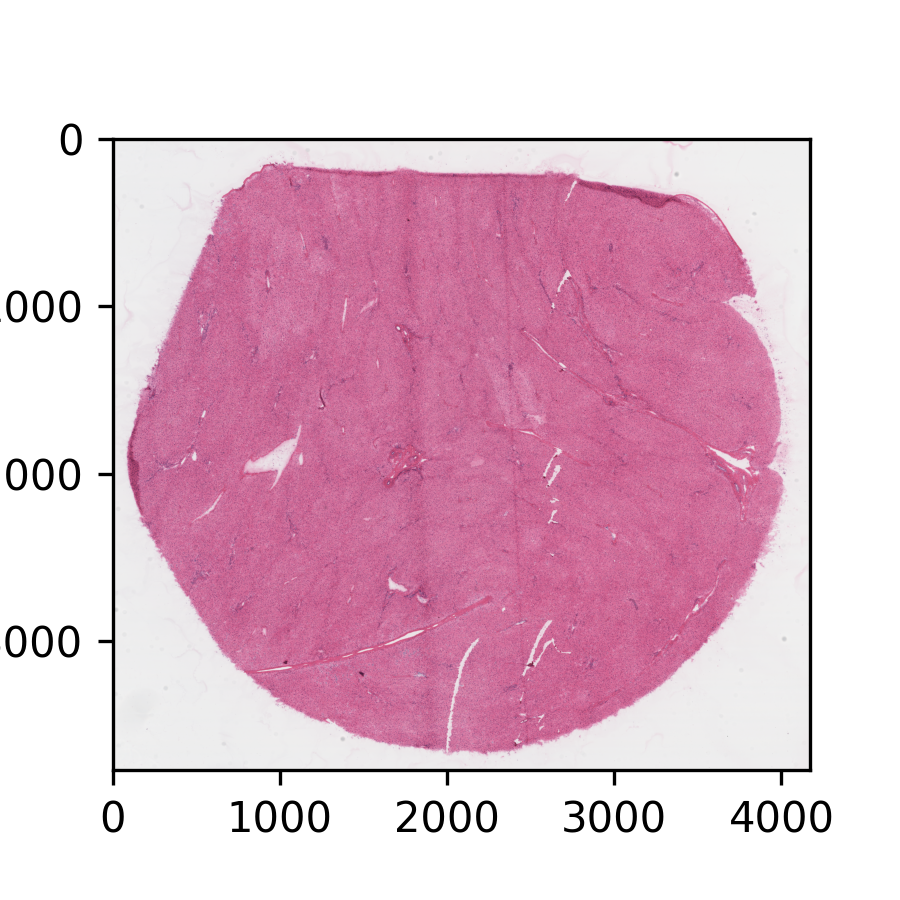

In [111]:
points = []
def onclick(event):
    ix, iy = event.xdata, event.ydata
    if ix is not None and iy is not None:
        points.append((ix, iy))
        print(f"Clicked pixel: x={ix:.2f}, y={iy:.2f}")


fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(he_imgs[idx])
plt.show()
cid = fig.canvas.mpl_connect('button_press_event', onclick)

In [112]:
len(points)

8

In [113]:
anchor_points.append(points)
print(len(anchor_points), "points annotated so far")
idx += 1
del points

12 points annotated so far


In [114]:
# Save self-annotated anchor points

anchor_path = '../data/desi/post_desi_anchors/'
if not os.path.exists(anchor_path):
    os.makedirs(anchor_path, exist_ok=True)

for filename, pts in zip(filenames, anchor_points):
    np.savetxt(os.path.join(data_path, filename.split('.')[0]+'.pts'), pts)

---

In [121]:
%matplotlib inline

In [134]:
from importlib import reload
reload(registration)

<module 'registration' from '/home/yinuo/Desktop/azizi_lab/IMS/notebooks/../util/registration.py'>

In [115]:
# Load self-annotated anchor points
data_path = '../data/desi/post_desi_anchors/'
anchor_points = IO.load_anchor_points(data_path)

In [117]:
ref_idx = 6
ref_name = filenames[ref_idx]
ref_img = he_imgs[ref_idx]
ref_pts = anchor_points[ref_idx]

M_dict = {}

for src_name, src_pts, img in zip(filenames, anchor_points, he_imgs):

    if src_name == ref_name:
        continue

    print('Computing M for {}...'.format(src_name))
    
    M = registration.get_affine_matrix(source=img,
                                       target=ref_img,
                                       pts_source=src_pts,
                                       pts_target=ref_pts
                                      )
    M_dict[src_name] = M

    del M, img, src_name
    gc.collect()

del src_pts, ref_pts

Computing M for HE_slice_07.tif...
Computing M for HE_slice_14.tif...
Computing M for HE_slice_20.tif...
Computing M for HE_slice_28.tif...
Computing M for HE_slice_34.tif...
Computing M for HE_slice_40.tif...
Computing M for HE_slice_55.tif...
Computing M for HE_slice_62.tif...
Computing M for HE_slice_71.tif...
Computing M for HE_slice_81.tif...
Computing M for HE_slice_93.tif...


In [120]:
%matplotlib inline

In [118]:
warped_imgs = np.zeros((len(he_imgs),) + ref_img.shape, dtype=np.uint8)

for i, filename in enumerate(filenames):
    if filename == ref_name:
        warped_imgs[i] = ref_img
    else:
        print('Warping image {}...'.format(filename))
        warped_imgs[i] = registration.affine_warp(he_imgs[i], ref_img.shape, M_dict[filename])


Warping image HE_slice_07.tif...
Warping image HE_slice_14.tif...
Warping image HE_slice_20.tif...
Warping image HE_slice_28.tif...
Warping image HE_slice_34.tif...
Warping image HE_slice_40.tif...
Warping image HE_slice_55.tif...
Warping image HE_slice_62.tif...
Warping image HE_slice_71.tif...
Warping image HE_slice_81.tif...
Warping image HE_slice_93.tif...


In [122]:
# Save Affine-warped images
out_path = '../data/desi/post_desi_HE_rigid/'
if not os.path.exists(out_path):
    os.makedirs(out_path, exist_ok=True)

for filename, img in zip(filenames, warped_imgs):
    tifffile.imwrite(os.path.join(out_path, filename), img)

#### Non-rigid Alignment

In [123]:
# Load pre-aligned images w/ Affine transformation
data_path = '../data/desi/post_desi_HE_rigid/'
filenames = [f for f in sorted(os.listdir(data_path))
             if f[-3:] == 'tif']
he_imgs = [tifffile.imread(os.path.join(data_path, f))
           for f in filenames]

In [135]:
# WSI non-rigid alignment & save warped images

out_path = '../data/desi/post_desi_HE_non_rigid/'
if not os.path.exists(out_path):
    os.makedirs(out_path, exist_ok=True)

ref_idx = 6
ref_name = filenames[ref_idx]
ref_img = he_imgs[ref_idx]
non_rigid_warped_imgs = np.zeros((len(he_imgs),) + ref_img.shape, dtype=np.uint8)

for i, (filename, src_img) in enumerate(zip(filenames, he_imgs)):
    print('Non-rigid Alignment / Warping on {}...'.format(filename))
    if filename == ref_name:
        warped_img = ref_img
    else:
        # dim: [C, Y, X]
        warped_img, _ = registration.non_rigid_warp(src_img, ref_img) 
    non_rigid_warped_imgs[i] = warped_img
    tifffile.imwrite(os.path.join(out_path, filename), img)


Non-rigid Alignment / Warping on HE_slice_07.tif...
Non-rigid Alignment / Warping on HE_slice_14.tif...
Non-rigid Alignment / Warping on HE_slice_20.tif...
Non-rigid Alignment / Warping on HE_slice_28.tif...
Non-rigid Alignment / Warping on HE_slice_34.tif...
Non-rigid Alignment / Warping on HE_slice_40.tif...
Non-rigid Alignment / Warping on HE_slice_48.tif...
Non-rigid Alignment / Warping on HE_slice_55.tif...
Non-rigid Alignment / Warping on HE_slice_62.tif...
Non-rigid Alignment / Warping on HE_slice_71.tif...
Non-rigid Alignment / Warping on HE_slice_81.tif...
Non-rigid Alignment / Warping on HE_slice_93.tif...


In [149]:
# Save final aligned images with FOV
r = 1300
ymid, xmid = non_rigid_warped_imgs[6].shape[0]//2+100, non_rigid_warped_imgs[0].shape[1]//2+100
out_path = '../data/desi/post_desi_HE_aligned/'
if not os.path.exists(out_path):
    os.makedirs(out_path, exist_ok=True)

for filename, img in zip(filenames, non_rigid_warped_imgs):
    trimmed_img = img[ymid-r:ymid+r, xmid-r:xmid+r]
    tifffile.imwrite(os.path.join(out_path, filename), trimmed_img)

del filename, img, trimmed_img

In [ ]:
# Save WSI image
tifffile.imwrite(os.path.join(out_path, 'HE_series.ome.tif'),
                 non_rigid_warped_imgs.transpose(3,0,1,2),  # Dim: [C, Z, Y, X]
                 metadata={'axes': 'CZYX'})

In [ ]:
# Sample Non-rigid alignment & visualization

# sample_moving_img = he_imgs[0]
# sample_fixed_img = he_imgs[18]
# sample_warped_img, bk_dxdy = IO.non_rigid_warp(sample_moving_img, sample_fixed_img)

# fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(10, 2.2))
# ax1.imshow(sample_moving_img)
# ax1.axis('off')
# ax1.set_title('Source')
# ax2.imshow(sample_fixed_img)
# ax2.axis('off')
# ax2.set_title('Target')
# ax3.imshow(backward_flow[0], cmap='coolwarm')
# ax3.axis('off')
# ax3.set_title('Optical Flow (dX)')
# ax4.imshow(backward_flow[1], cmap='coolwarm')
# ax4.axis('off')
# ax4.set_title('Optical Flow (dY)')
# ax5.imshow(sample_warped_img)
# ax5.axis('off')
# ax5.set_title('Source (warped)')

# plt.tight_layout()
# plt.show()

### Post-modality multi-modal alignment

- Backbone: H&E
- Source: CyCIF or DESI

### CyCIF alignment

**TODO**
- Load annotated points for rigid alignment
- Apply Rigid alignment across all *channels* and all *Z-slices*
- Apply Non-rigid alignemnt across all *channels* and all *Z-slices* (reusing the same `bk_dxdy` for all C's in the same `Z[i]`)
- Save the annotated imgs (make sure the name-channel key-value pair is correct)

#### Data loading & alignment

In [ ]:
from skimage import io

In [ ]:
# # Alignment w/ a reference X work well

# data_path = '../data/cycif/adj/'
# # dapi_path = '../data/cycif/dapi/'
# res_path = '../data/cycif/aln/'
# ref_slide = 'CyIF_tiss_38.ome.tif'
# # ref_slide = None

# series = 2
# do_micro = False
# aln_to_ref = False 
# # micro_res = 1000

# registrar, _, _ = registration.run_valis(src_dir=data_path,
#                                          res_dir=res_path,
#                                          ref_slide=ref_slide,
#                                          micro=do_micro,
#                                          image_type='fluorescence',
#                                          kill_jvm=True)

In [ ]:
data_path = '../data/cycif/adj/'
annot_imgs = IO.load_annot_tiffs(data_path)
filenames = list(annot_imgs.keys())

#### Rigid Alignment

In [ ]:
# Extract DAPI chans for interactive anchor pt annotations & rigid alignment
dapi_imgs = [img['DAPI'] for _, img in annot_imgs.items()]

##### Interactive anchor point annotations

---

In [ ]:
%matplotlib widget

In [ ]:
idx = 0

In [ ]:
points = []
def onclick(event):
    ix, iy = event.xdata, event.ydata
    if ix is not None and iy is not None:
        points.append((ix, iy))
        print(f"Clicked pixel: x={ix:.2f}, y={iy:.2f}")


fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(dapi_imgs[idx])
plt.show()
cid = fig.canvas.mpl_connect('button_press_event', onclick)

In [ ]:
print(points)
print('\n', len(points))

In [ ]:
# anchor_points = []
anchor_points.append(points)
print(len(anchor_points), "points annotated so far")
idx += 1
del points

In [ ]:
# Save self-annotated anchor points

anchor_path = '../data/cycif/anchor_pts/'
if not os.path.exists(anchor_path):
    os.makedirs(anchor_path, exist_ok=True)

for filename, pts in zip(filenames, anchor_points):
    np.savetxt(os.path.join(anchor_path, filename.split('.')[0]+'.pts'), pts)

---

In [ ]:
%matplotlib inline

In [ ]:
# Load self-annotated anchor points
anchor_path = '../data/cycif/anchor_pts/'
anchor_points = IO.load_anchor_points(anchor_path)

Check DAPI warping quality:

In [ ]:
# dapi_imgs = [img['DAPI'] for _, img in annot_imgs.items()]

ref_idx = 11
ref_name = filenames[ref_idx]
ref_pts = anchor_points[ref_idx]
ref_img = dapi_imgs[ref_idx]

M_dict = {}
for src_name, src_pts, img in zip(filenames, anchor_points, dapi_imgs):
    if src_name == ref_name:
        continue

    print('Computing M for {}...'.format(src_name))
    
    M = registration.get_affine_matrix(source=img,
                                       target=ref_img,
                                       pts_source=src_pts,
                                       pts_target=ref_pts)
    M_dict[src_name] = M

    del M, img, src_name, src_pts
    gc.collect()

In [ ]:
warped_imgs = np.zeros((len(dapi_imgs),) + ref_img.shape, dtype=np.uint8)

for i, filename in enumerate(filenames):
    if filename == ref_name:
        warped_imgs[i] = ref_img
    else:
        print('Warping image {}...'.format(filename))
        warped_imgs[i] = registration.affine_warp(dapi_imgs[i], ref_img.shape, M_dict[filename])


In [ ]:
# Save Affine-warped images (DEBUG: only DAPI for now)
out_path = '../data/cycif/aligned/rigid/'
if not os.path.exists(out_path):
    os.makedirs(out_path, exist_ok=True)

for filename, img in zip(filenames, warped_imgs):
    tifffile.imwrite(os.path.join(out_path, filename), img)

#### Non-rigid Alignment

(Note: only DAPI channel for now!!!)

In [ ]:
# Load pre-aligned images w/ Affine transformation
data_path = '../data/cycif/aligned/rigid/'
filenames = [f for f in sorted(os.listdir(data_path))
             if f[-3:] == 'tif']
cyif_imgs = [tifffile.imread(os.path.join(data_path, f))
           for f in filenames]

# Note: to read multi-channel images, use IO.load_annot_tiffs

In [ ]:
# WSI non-rigid alignment & save warped images

out_path = '../data/cycif/aligned/non_rigid/'
if not os.path.exists(out_path):
    os.makedirs(out_path, exist_ok=True)

ref_idx = 18
ref_name = filenames[ref_idx]
ref_img = cyif_imgs[ref_idx]
non_rigid_warped_imgs = np.zeros((len(cyif_imgs),) + ref_img.shape, dtype=np.uint8)

for i, (filename, src_img) in enumerate(zip(filenames, cyif_imgs)):
    print('Non-rigid Alignment / Warping on {}...'.format(filename))
    if filename == ref_name:
        warped_img = ref_img
    else:
        warped_img, _ = registration.non_rigid_warp(src_img, ref_img)
    non_rigid_warped_imgs[i] = warped_img
    
    # tifffile.imwrite(os.path.join(out_path, filename), img)


In [ ]:
out_path

In [ ]:
non_rigid_warped_imgs.shape

In [ ]:
# Save WSI image

# Only DAPI
tifffile.imwrite(os.path.join(out_path, 'CyIF_series.ome.tif'),
                 non_rigid_warped_imgs,
                 metadata={'axes': 'ZYX'})


In [ ]:
# Note: to save Multi-channel WSI image, please 
# construct the nested dict of annot_imgs: str[filename, str[chan_name, chan]] 
# and use IO.save_annot_tiffs

---